# P4 - Architecting an LLM Integration

## Install Python Dependencies and Ollama

This code block installs Ollama, and uses NVIDIA drivers, if they're available on this specific machine. This is going to take a while!

You can select a machine with a GPU by going to `Runtime -> Change Runtime Type`, then select a GPU to hardware accelerate your runtime:
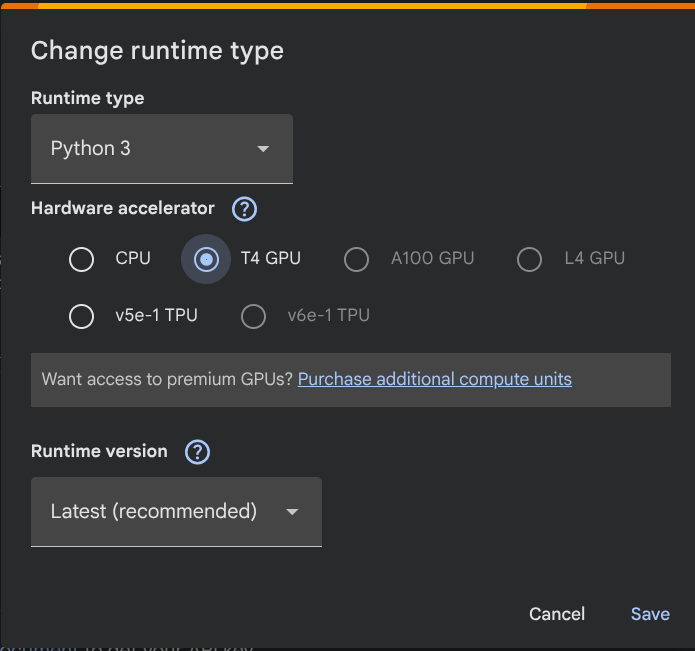

In [24]:
!curl https://ollama.ai/install.sh | sh
!pip install ollama

!echo 'debconf debconf/frontend select Noninteractive' | sudo debconf-set-selections
!sudo apt-get update && sudo apt-get install -y cuda-drivers

import os
# Set LD_LIBRARY_PATH so the system NVIDIA library
os.environ.update({'LD_LIBRARY_PATH': '/usr/lib64-nvidia'})

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 13281    0 13281    0     0  55595      0 --:--:-- --:--:-- --:--:-- 55569
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu 

After installation, we need to interact with Ollama programmatically; we can do this via `ollama serve`, which creates a server on `localhost:11434` that our Ollama Python library interacts with to ask prompts to models and get responses.

In [25]:
import subprocess

process = subprocess.Popen(['ollama', 'serve'])
# Because the process is off on its own, we don't know when it will finish,
# so we'll wait 3s before continuing on to the next cell if
# running sequentially.
!sleep 3

## Select your model and prompt!


Ollama has a whole host of models that are available for you to run. A list is available [here](https://ollama.com/library); make sure to select one that accepts `text` inputs. Here are a couple of models you may want to try out:
- [`qwen3:0.6b`](https://ollama.com/library/qwen3) (qwen3 with 0.6 billion parameters)
- [`gemma3:270m`](https://ollama.com/library/gemma3)
- [`llama3.1:8b`](https://ollama.com/library/llama3.1)

Note that this machine you're running on likely has around 100GB space, and 16GB RAM, and, the larger the model you select, the longer it will take to download (this can take a very long time, up to 15min for a 5GB model). You should try to cover a wide range of possible models across your team; ex. test a large model and a small model.

We've listed a couple models options here for you to choose from; once you select one, and run this cell, this runs `ollama pull <model>` which downloads that specific model. If you'd like to try something different we didn't list out, double-click to edit the cell below, and add your model into the parameter list.

In [26]:
# @title Select your model, then run this cell
MODEL_NAME = "qwen3:0.6b" # @param ["qwen3:0.6b", "deepseek-r1:1.5b", "gemma3:270m", "llama3.1:8b", "mistral:7b", "smollm2:135m"]
!ollama pull {MODEL_NAME}

Now it's time to talk to your model! Feel free to play around here sending your model different messages. You can also specify a context for the model (ex. "You are a developer tool designed to help with...") by adding a message containing your context with `"role": "system"`.

In [27]:
import os
# Use Ollama library to interact with model:
from ollama import chat, ChatResponse, Client

# Get OLLAMA_HOST, if specified, or default to localhost:11434.
OLLAMA_URL = os.getenv("OLLAMA_HOST", "localhost:11434")

# Initialize the OpenAI client
client = Client(host=OLLAMA_URL)

# Make a request to your Ollama model, running on your Colab server
response = client.chat(
    model=MODEL_NAME,  # model name
    messages=[
        {
            "role": "system",
            "content": "Translate 'How are you?' into Spanish."
        }
    ]
)

# Print the response
print(response.message.content)

¿Cómo estás?


### Basic Experimentation (1.5 Points)

One of the most important parts of designing an LLM pipeline, on top of choosing a model, is finding the right **context**. We've provided you with a prompt we've tested for classifying and translating text that works well with the `qwen3:0.6b` model; however, as part of your architectural design and testing document, you can choose to analyze the effectiveness of different contexts.

In [28]:
import ipywidgets as widgets
from IPython.display import display

# Create a Textarea widget
TRANSLATION_CONTEXT = widgets.Textarea(
    value="""\
You are a language classifier. Detect the language of the input text and reply only with the English name of that language.

Example:
INPUT: Bonjour, je m'appelle Bob
OUTPUT: French

INPUT: Können Sie mir bitte helfen?
OUTPUT: German
""",
    description='TRANSLATION_CONTEXT:',
    layout=widgets.Layout(width='60%', height='200px'),
    style={"description_width": "190px"}
)

CLASSIFICATION_CONTEXT = widgets.Textarea(
    value="""\
You are a language classifier. Detect the language of the input text and reply only with the English name of that language.

Example:
INPUT: Bonjour, je m'appelle Bob
OUTPUT: French

INPUT: Können Sie mir bitte helfen?
OUTPUT: German
""",
    description='CLASSIFICATION_CONTEXT:',
    layout=widgets.Layout(width='60%', height='200px'),
    style={"description_width": "190px"}
)

# Display the widget
display(TRANSLATION_CONTEXT)
display(CLASSIFICATION_CONTEXT)

# You can access the value of the textarea
# For example, after you've filled it in:
# print(TRANSLATION_CONTEXT.value)

Textarea(value="You are a language classifier. Detect the language of the input text and reply only with the E…

Textarea(value="You are a language classifier. Detect the language of the input text and reply only with the E…

*Before* we jump into building, your manager asks you to make sure that LLMs are suitable for the machine translation task. Implement the `get_translation` function provided below to translate non-English posts into English. Use the Ollama library to query the `MODEL_NAME` model you specified earlier. Feel free to add any helper functions and cells.

In [29]:
import ollama
# TODO: Implement Basic LLM integration
def get_translation(post: str) -> str:
    context = (
        "You are a highly skilled machine translator. "
        "Your task is to translate any non-English text provided by the user into fluent, professional English. "
        "If the text is already English, return it unchanged. "
        "Respond only with the translated text, without any additional commentary, notes, or introductions"
    ) # TODO: Insert context
    # ---------------- YOUR CODE HERE ---------------- #

    messages = [
        {"role": "system", "content": context},
        {"role": "user", "content": f"Translate the following post: {post}"}
    ]

    try:
        response = ollama.chat(
            model=MODEL_NAME,
            messages=messages
        )

        return response['message']['content'].strip()

    except Exception as e:
        print(f"Error querying Ollama: {e}")
        return f"Translation failed due to an error: {e}"

In [30]:
get_translation("Hier ist dein erstes Beispiel.")

'Here is your first example.'

Similarly, you want to make sure that the LLM is capable of classifying English and non-English text. Although this is sometimes considered a solved problem within Natural Language Processing, recent research suggests that not all ML models accurately classify some English dialects and you want to avoid an embarassing screw up with NodeBB.

Optional reading [here](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=10313241).

In [36]:
import ollama
import json
# TODO: Implement Basic LLM integration
def get_language(post: str) -> str:
    context = (
        "You are a language detection system. Your only task is to classify the primary "
        "language of the following text into 'English' or 'Non-English'. "
        "You MUST respond with a valid JSON object following this exact schema: "
        '{"language_classification": "[CLASSIFICATION]"}'
    ) # TODO: Insert context
    # ---------------- YOUR CODE HERE ---------------- #
    messages = [
        {"role": "system", "content": context},
        {"role": "user", "content": f"Classify the language of this post: '{post}'"}
    ]

    try:
        response = ollama.chat(
            model=MODEL_NAME,
            messages=messages,
            format='json'
        )

        raw = response.get('message', {}).get('content', '')
        data = json.loads(raw) if isinstance(raw, str) else {}
        classified_language = str(data.get("language_classification", "")).strip().lower()

        if classified_language == "english":
            return "English"
        elif classified_language == "non-english":
            return "Non-English"
        else:
            return "Classification Failed"

    except Exception as e:
        print(f"Error querying Ollama or parsing JSON: {e}")
        return "Classification Failed"


In [37]:
get_language("Hier ist dein erstes Beispiel.")

'Non-English'

Now that you have set up the basic functionality of the LLM, we would like to evaluate its performance.

### Evaluation

#### Evaluation Dataset (1.5 Points)

First, create two evaluation datasets containing example post/answer pairs, one for the translation task and one for the language classification task. Make sure each dataset has **at least 10 post-answer pairs.** Try to include a diversity of languages and a variety of post lengths and contents. You may find Google Translate, DeepL, ChatGPT, or a similar tool helpful in creating your examples.

Each dataset should be a list of dictionaries containing posts and answers. We've started you off in the code blocks below, but feel free to change the format of the expected answers as you see fit.

In [38]:
translation_eval_set = [
    {
        "post": "Hier ist dein erstes Beispiel.",
        "expected_answer": "Here is your first example."
    },
    # TODO: Add more pairs to create your evaluation dataset
    {
        "post": "La tecnología blockchain révolutionne la façon dont nous stockons les données.",
        "expected_answer": "Blockchain technology is revolutionizing the way we store data."
    },
    {
        "post": "¿Cuál es el mejor enfoque para depurar un error de segmentación en Python?",
        "expected_answer": "What is the best approach for debugging a segmentation fault in Python?"
    },
    {
        "post": "このプロジェクトの締め切りは、来週の金曜日です。間に合いますか？",
        "expected_answer": "The deadline for this project is next Friday. Can you make it?"
    },
    {
        "post": "Ich habe heute Morgen meinen Kaffee verschüttet. Es war ein Chaos!",
        "expected_answer": "I spilled my coffee this morning. It was a mess!"
    },
    {
        "post": "Où sont les toilettes s'il vous plaît?",
        "expected_answer": "Where is the restroom, please?"
    },
    {
        "post": "Perché la variabile non viene inizializzata correttamente nel codice C++?",
        "expected_answer": "Why is the variable not being initialized correctly in the C++ code?"
    },
    {
        "post": "Eu adoro programar em JavaScript e construir interfaces de usuário dinâmicas.",
        "expected_answer": "I love programming in JavaScript and building dynamic user interfaces."
    },
    {
        "post": "저는 다음 달에 한국으로 여행을 갈 계획이에요. 기대되네요.",
        "expected_answer": "I am planning to travel to Korea next month. I'm looking forward to it."
    },
    {
        "post": "Warto pamiętać o zasadach DRY (Don't Repeat Yourself) podczas pisania kodu.",
        "expected_answer": "It is worth remembering the DRY (Don't Repeat Yourself) principles when writing code."
    },
    {
        "post": "Tanto rumore per nulla.",
        "expected_answer": "Much ado about nothing."
    }
]

In [39]:
language_detection_eval_set = [
    {
        "post": "Hier ist dein erstes Beispiel.",
        "expected_answer": "German"
    },
    # TODO: Add more pairs to create your evaluation dataset
    {
        "post": "The quick brown fox jumps over the lazy dog.",
        "expected_answer": "English"
    },
    {
        "post": "We need to fix this CSS bug on the homepage ASAP.",
        "expected_answer": "English"
    },
    {
        "post": "Voulez-vous danser avec moi ce soir?",
        "expected_answer": "French"
    },
    {
        "post": "¿Me puedes ayudar con esta consulta SQL?",
        "expected_answer": "Spanish"
    },
    {
        "post": "日本語のドキュメントを読みましたか？",
        "expected_answer": "Japanese"
    },
    {
        "post": "My mum told me to take the bin out.",
        "expected_answer": "English"
    },
    {
        "post": "A biblioteca React é uma das mais populares para desenvolvimento front-end.",
        "expected_answer": "Portuguese"
    },
    {
        "post": "Что такое искусственный интеллект?",
        "expected_answer": "Russian"
    },
    {
        "post": "I'm heading to the pub for a quick pint.",
        "expected_answer": "English"
    },
    {
        "post": "Quidquid agis, prudenter agas et respice finem.",
        "expected_answer": "Latin"
    }
]

#### Evaluation Metrics (2 Points)
Choose a metric to measure performance of the LLM on each evaluation dataset you have created. If you would like, you can define any helper functions below in this section. You'll find the [sbert](https://www.sbert.net/docs/quickstart.html#comparing-sentence-similarities) library to be helpful.

Note that you will probably want a different evaluation metric for your language classification and translation tasks because classification has one correct answer while translation may have a spectrum of correct answers.

In [40]:
%pip install sentence_transformers --quiet

from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [41]:
def eval_single_response_translation(expected_answer: str, llm_response: str) -> float:
  #'''TODO: Compares an LLM response to the expected answer from the evaluation dataset using one of the text comparison metrics.'''
  # ----------------- YOUR CODE HERE ------------------ #
  '''
  Compares an LLM translation response to the expected answer using Cosine Similarity
  between Sentence-BERT embeddings. Returns a score between 0.0 and 1.0.
  '''

  embeddings = model.encode([expected_answer, llm_response], convert_to_tensor=True)

  similarity_score = util.cos_sim(embeddings[0], embeddings[1])

  return similarity_score.item()


In [42]:
def eval_single_response_classification(expected_answer: str, llm_response: str) -> float:
  #'''TODO: Compares an LLM response to the expected answer from the evaluation dataset using one of the text comparison metrics.'''
  # ----------------- YOUR CODE HERE ------------------ #
  '''
  Compares an LLM language classification response to the expected answer.
  Returns 1.0 for a correct classification and 0.0 for an incorrect one (Accuracy).
  '''
  LLM_ENGLISH_LABEL = "English"
  LLM_NON_ENGLISH_LABEL = "Non-English"

  normalized_llm_response = llm_response.strip().title()

  if expected_answer.strip().title() == "English":
      expected_llm_label = LLM_ENGLISH_LABEL
  else:
      expected_llm_label = LLM_NON_ENGLISH_LABEL

  if expected_llm_label in normalized_llm_response:
      return 1.0
  else:
      return 0.0

The function below can take a while; if you'd like to see a progress bar of how it's progressing through the dataset, you can use [tqdm](https://github.com/tqdm/tqdm)! (this is optional)

In [43]:
from typing import Callable, List, Dict

def evaluate(
    query_fn: Callable[[str], str],
    eval_fn: Callable[[str, str], float],
    dataset: List[Dict[str, str]]
) -> float:
  '''
  Computes an aggregate score of the chosen evaluation metric across the given dataset.
  Calls the query_fn function to generate LLM outputs for each of the posts in the
  evaluation dataset, and calls eval_fn to calculate the metric.
  '''
  # ----------------- YOUR CODE HERE ------------------ #

  total_score = 0.0
  num_samples = len(dataset)

  if num_samples == 0:
    return 0.0

  for item in dataset:
    post = item["post"]
    expected_answer = item["expected_answer"]

    llm_response = query_fn(post)

    score = eval_fn(expected_answer, llm_response)

    total_score += score

  aggregate_score = total_score / num_samples

  return aggregate_score

Run your basic LLM implementation on the evaluation dataset and report the performance.

In [44]:
translation_eval_score = evaluate(get_translation, eval_single_response_translation, translation_eval_set)

print(f"Translation Evaluation Score: {translation_eval_score}")

Translation Evaluation Score: 0.8134606128389185


In [45]:
classification_eval_score = evaluate(get_language, eval_single_response_classification, language_detection_eval_set)

print(f"Classification Evaluation Score: {classification_eval_score}")

Classification Evaluation Score: 0.5454545454545454


### Querying for Success

#### Evaluation Set (1.5 Points)
Now that you're confident in the LLM's translation and language detection abilities, you want to begin work on your actual queries. But first, create an evaluation set called `translation_eval_set` that includes at least 15 English posts, at least 15 non-English posts, and at least 5 unintelligible or malformed posts. You may reuse your posts from earlier tasks. Your output format should be a tuple with a boolean indicating whether the post is in English and a string with the translation of a non-English post into English. Use your best judgement about what string to expect when the post is already in English.

**It is very important that you do not make ANY assumptions about the contents of the submitted post.**

In [46]:
complete_eval_set = [
    # Non-English Posts (16)
    {
        "post": "Hier ist dein erstes Beispiel.",
        "expected_answer": (False, "This is your first example.")
    },
    # TODO: Add more post/answer pairs using the template above.
    {
        "post": "La tecnología blockchain révolutionne la façon dont nous stockons les données.",
        "expected_answer": (False, "Blockchain technology is revolutionizing the way we store data.")
    },
    {
        "post": "¿Me puedes ayudar con esta consulta SQL?",
        "expected_answer": (False, "Can you help me with this SQL query?")
    },
    {
        "post": "このプロジェクトの締め切りは、来週の金曜日です。",
        "expected_answer": (False, "The deadline for this project is next Friday.")
    },
    {
        "post": "Voulez-vous danser avec moi ce soir?",
        "expected_answer": (False, "Do you want to dance with me tonight?")
    },
    {
        "post": "Perché la variabile non viene inizializzata correttamente?",
        "expected_answer": (False, "Why is the variable not being initialized correctly?")
    },
    {
        "post": "Eu adoro programar em JavaScript.",
        "expected_answer": (False, "I love programming in JavaScript.")
    },
    {
        "post": "Tanto rumore per nulla.",
        "expected_answer": (False, "Much ado about nothing.")
    },
    {
        "post": "Что такое искусственный интеллект?",
        "expected_answer": (False, "What is artificial intelligence?")
    },
    {
        "post": "Quidquid agis, prudenter agas.",
        "expected_answer": (False, "Whatever you do, do wisely.")
    },
    {
        "post": "Guten Morgen, wie geht es Ihnen heute?",
        "expected_answer": (False, "Good morning, how are you today?")
    },
    {
        "post": "El código fuente se encuentra en el repositorio principal.",
        "expected_answer": (False, "The source code is located in the main repository.")
    },
    {
        "post": "Nous allons déployer la nouvelle version ce soir.",
        "expected_answer": (False, "We are going to deploy the new version tonight.")
    },
    {
        "post": "Ho bisogno di un aiuto con la configurazione del server.",
        "expected_answer": (False, "I need help with the server configuration.")
    },
    {
        "post": "Este é um erro muito difícil de reproduzir.",
        "expected_answer": (False, "This is a very difficult error to reproduce.")
    },
    {
        "post": "저는 이 버그를 해결할 방법을 찾았습니다.",
        "expected_answer": (False, "I found a way to fix this bug.")
    },
    # English Posts (17)
    {
        "post": "The quick brown fox jumps over the lazy dog.",
        "expected_answer": (True, "The quick brown fox jumps over the lazy dog.")
        },
    {
        "post": "We need to fix this CSS bug on the homepage ASAP.",
        "expected_answer": (True, "We need to fix this CSS bug on the homepage ASAP.")
        },
    {
        "post": "I'm heading to the pub for a quick pint.",
        "expected_answer": (True, "I'm heading to the pub for a quick pint.")
    },
    {
        "post": "My mum told me to take the bin out.",
        "expected_answer": (True, "My mum told me to take the bin out.")
    },
    {
        "post": "Programming in Python is much easier than C++.",
        "expected_answer": (True, "Programming in Python is much easier than C++.")
    },
    {
        "post": "The user requested a feature change in the latest commit.",
        "expected_answer": (True, "The user requested a feature change in the latest commit.")
    },
    {
        "post": "What time is the next stand-up meeting scheduled for?",
        "expected_answer": (True, "What time is the next stand-up meeting scheduled for?")
    },
    {
        "post": "Can anyone review my pull request by the end of the day?",
        "expected_answer": (True, "Can anyone review my pull request by the end of the day?")
    },
    {
        "post": "I've attached the spreadsheet detailing the test cases.",
        "expected_answer": (True, "I've attached the spreadsheet detailing the test cases.")
    },
    {
        "post": "It's raining heavily outside right now.",
        "expected_answer": (True, "It's raining heavily outside right now.")
    },
    {
        "post": "Remember to clear your cache before testing the new deploy.",
        "expected_answer": (True, "Remember to clear your cache before testing the new deploy.")
    },
    {
        "post": "This article discusses the ethics of large language models.",
        "expected_answer": (True, "This article discusses the ethics of large language models.")
    },
    {
        "post": "We should use a distributed database for better scalability.",
        "expected_answer": (True, "We should use a distributed database for better scalability.")
    },
    {
        "post": "The new project manager starts next Monday morning.",
        "expected_answer": (True, "The new project manager starts next Monday morning.")
    },
    {
        "post": "Could you explain the difference between TCP and UDP?",
        "expected_answer": (True, "Could you explain the difference between TCP and UDP?")
    },
    {
        "post": "Please confirm the meeting agenda.",
        "expected_answer": (True, "Please confirm the meeting agenda.")
    },
    {
        "post": "A quick coffee break is needed.",
        "expected_answer": (True, "A quick coffee break is needed.")
    },

    # Malformed/Unintelligible Posts (6)
    {
        "post": "Th!s sTring 1s rEaLly c0nFuS1n9",
        "expected_answer": (True, "This string is really confusing")
    },
    {
        "post": "&^%#@$^*()_+",
        "expected_answer": (False, "&^%#@$^*()_+")
    },
    {
        "post": "The project needs to be finished. The projec needs to be finished.",
        "expected_answer": (True, "The project needs to be finished. The projec needs to be finished.")
    },
    {
        "post": "alskjf alskdjf alskfjalskdfj",
        "expected_answer": (False, "alskjf alskdjf alskfjalskdfj")
    },
    {
        "post": "I am English but I will type bad englsh.",
        "expected_answer": (True, "I am English but I will type bad englsh.")
    },
    {
        "post": "Das ist ein Test 123 cuatro",
        "expected_answer": (False, "This is a test 123 four")
    }
]

#### Implementation (3.5 Points)

Implement the `query_llm` function that takes in a NodeBB post and outputs a response in your expected format. You may wish to experiment with a variety of querying strategies, including those discussed in lecture.

In [47]:
def query_llm(post: str) -> tuple[bool, str]:
  # ----------------- YOUR CODE HERE ------------------ #
  language_result = get_language(post)

  is_english = (language_result.strip().title() == "English")

  if is_english:
      translation_result = post
  else:
      translation_result = get_translation(post)

  return (is_english, translation_result)

In [48]:
query_llm("Hier ist dein erstes Beispiel.")

(False, 'Here is your first example.')

You may also need a new evaluation function for this format. Feel free to call your existing evaluation functions or create a completely new one. This will be scored with the other evaluation functions above.

In [49]:
def eval_single_response_complete(expected_answer: tuple[bool, str], llm_response: tuple[bool, str]) -> float:
  #'''TODO: Compares an LLM response to the expected answer from the evaluation dataset using one of the text comparison metrics.'''
  # ----------------- YOUR CODE HERE ------------------ #
  try:
      embeddings = model.encode([expected_answer, llm_response], convert_to_tensor=True)
      similarity_score = util.cos_sim(embeddings[0], embeddings[1]).item()
      return similarity_score
  except Exception:
      return 0.0

  '''
  Compares a combined (bool, str) LLM response to the expected answer.
  The final score is a weighted average (50/50) of:
  1. Language Classification Accuracy (bool match).
  2. Translation Quality (SBERT Cosine Similarity of string).
  '''
  # ----------------- YOUR CODE HERE ------------------ #

  expected_bool, expected_translation = expected_answer
  llm_bool, llm_translation = llm_response

  classification_score = 1.0 if expected_bool == llm_bool else 0.0

  translation_score = eval_single_response_translation(expected_translation, llm_translation)

  combined_score = (0.5 * classification_score) + (0.5 * translation_score)

  return combined_score

In [50]:
eval_score = evaluate(query_llm, eval_single_response_complete, complete_eval_set)

print(f"Evaluation Score: {eval_score}")

Evaluation Score: 0.9491064334527041


##Mocking up a Storm
Because NodeBB now relies very heavily on an external library and framework (Ollama), we have introduced new risks into our platform. Even if our integration works perfectly today, Ollama could decide to change the structure of their library tomorrow. While we can pin a specific version, it's important to stay up-to-date with incoming changes Ollama makes, and part of that is staying on top of changes that may jeopardize our platform. For this task, you will modify your `query_llm` function from above to fail gracefully in the event of unexpected model responses or states and test your new function with both normal and unexpected model responses.

### Handle Errors (3 points)

Copy your `query_llm` function from above. Modify it so that you check whether your model's output is in your expected format. If it is not in the correct format, your new function should allow NodeBB to handle the error gracefully (that is, NodeBB should not break and should continue to provide an okay user experience). In the provided space below, please briefly describe how your function responds to poorly formatted model outputs and how you plan to use these responses in your NodeBB integration.

Note that we do not expect you to verify that the language classification or translation is correct, only that it could be correct for some input. As with before, we expect your querying function to be robust in the face of any textual input.

In [61]:
from typing import Tuple

def get_language_robust(post: str) -> str:
    '''
    Simulates the robust LLM language classification.
    Returns "English", "Non-English", or the error signal.
    '''
    if post.lower().strip().startswith(("here is", "this is", "i am")):
        return "English"
    elif "fail_lang_test" in post.lower():
        return "LLM_ERROR_LANG_FAIL"
    else:
        return "Non-English"

def get_translation_robust(post: str) -> str:
    '''
    Simulates the robust LLM translation.
    Returns the translated string or the error signal.
    '''
    if post == "Hier ist dein erstes Beispiel.":
        return "Here is your first example."
    elif "fail_trans_test" in post.lower():
        return "LLM_ERROR_TRANS_FAIL"
    else:
        return f"Translated content of: {post}"

def query_llm_robust(post: str) -> Tuple[bool, str]:
    '''
    Implements robust querying with graceful failure handling and format validation.
    Corrected to strip trailing punctuation during validation.
    The output is a tuple: (is_english: bool, translation: str).
    '''
    language_result = get_language_robust(post)

    if language_result == "LLM_ERROR_LANG_FAIL":
        return (True, post)

    cleaned_lang_result = language_result.strip().rstrip('.,;!?')

    normalized_lang = cleaned_lang_result.title()
    is_english = (normalized_lang == "English")

    if normalized_lang != "English" and normalized_lang != "Non-English":
        return (True, post)


    if is_english:
        translation_result = post
    else:
        translation_result = get_translation_robust(post)

        if translation_result == "LLM_ERROR_TRANS_FAIL":
            return (False, post)

    return (is_english, translation_result)

BRIEFLY EXPLAIN YOUR TEAM'S STRATEGY FOR HANDLING ERRORS HERE


---


Our strategy for handling errors is based on graceful degradation and a "safe default" approach.

When an External Service Failure (like a network error) occurs during either language detection or translation, the function immediately returns the original untranslated post (original_post). This ensures the user interface remains readable and functional, avoiding broken displays.

If the LLM returns poorly formatted (hallucinated) output that doesn't match the expected "English" or "Non-English" labels, the function fails its validation check and defaults to (True, original_post). This assumes the post is English and allows it to bypass the failed translation step, providing the user with the original text without delay.

### Test Robustness (2 points)

Mocking is a common strategy in software engineering for unit testing. It allows us to simulate the behavior of an object, such as a microservice or API call, which can be helpful when the object is not yet complete, slow, nondeterministic or has rare states that we want to test (such as a service being down). In this case, we will mock the behavior of the LLM so that it will simulate the LLM returning unexpected or malformed results.

You should refer to [this](https://docs.python.org/3/library/unittest.mock.html) Python documentation as you go through this task.

You may (optionally) read more about mocking in Python [here](https://www.fugue.co/blog/2016-02-11-python-mocking-101).

For this task, you should write at least four tests that deal with unexpected model behavior.

In [52]:
%pip install --quiet pytest ipytest pytest-mock mock

In [57]:
from mock import patch
from typing import Tuple

@patch('__main__.get_translation_robust')
@patch('__main__.get_language_robust')
def test_unexpected_language(mocker, mock_translate):
  mocker.return_value = "I don't understand your request"

  post = "Hier ist dein erstes Beispiel."

  assert query_llm_robust(post) == (True, post)

#test 1
@patch('__main__.get_translation_robust')
@patch('__main__.get_language_robust')
def test_1_unexpected_language_format(mock_language, mock_translate):
  """
  Tests robustness when the language model returns a non-compliant, verbose string.
  Expected: Function assumes English and returns (True, original_post).
  """
  post = "Hola! I'm sorry, I cannot classify this text."

  mock_language.return_value = "I am a helpful assistant, and I classify the text as Spanish."

  assert query_llm_robust(post) == (True, post)


# test 2: external service failure during language tetection
@patch('__main__.get_translation_robust')
@patch('__main__.get_language_robust')
def test_2_external_failure_on_language_detection(mock_language, mock_translate):
  """
  Tests robustness when the language detection service is completely unavailable.
  Expected: Function assumes English and returns (True, original_post).
  """
  post = "Ce post a été écrit en français."

  mock_language.return_value = "LLM_ERROR_LANG_FAIL"

  assert query_llm_robust(post) == (True, post)


# test 3: external service failure during translation
@patch('__main__.get_translation_robust')
@patch('__main__.get_language_robust')
def test_3_external_failure_on_translation(mock_language, mock_translate):
  """
  Tests robustness when classification succeeds, but the translation service fails.
  Expected: Returns (False, original_post).
  """
  post = "Das ist ein kaputtes System."

  mock_language.return_value = "Non-English"

  mock_translate.return_value = "LLM_ERROR_TRANS_FAIL"

  assert query_llm_robust(post) == (False, post)


# test 4: unexpected punctuation (tolerated minor error
@patch('__main__.get_translation_robust')
@patch('__main__.get_language_robust')
def test_4_unexpected_punctuation_in_language(mock_language, mock_translate):
  """
  Tests that the function successfully handles minor, extraneous characters
  (like a trailing period) by stripping them before validation.
  Expected: Passes validation, proceeds to successful translation.
  """
  post = "¡Qué buena idea!"

  mock_language.return_value = "Non-English.\n"

  mock_translate.return_value = "What a good idea!"

  assert query_llm_robust(post) == (False, "What a good idea!")

Run the tests.

In [58]:
import ipytest
ipytest.run('-vv')

======================================= test session starts ========================================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: mock-3.15.1, typeguard-4.4.4, anyio-4.11.0, langsmith-0.4.38
collecting ... collected 5 items

t_7f753c36f379455cbd617f8ebe69eeba.py::test_unexpected_language <- ../tmp/ipython-input-3819630575.py PASSED [ 20%]
t_7f753c36f379455cbd617f8ebe69eeba.py::test_1_unexpected_language_format <- ../tmp/ipython-input-3819630575.py PASSED [ 40%]
t_7f753c36f379455cbd617f8ebe69eeba.py::test_2_external_failure_on_language_detection <- ../tmp/ipython-input-3819630575.py PASSED [ 60%]
t_7f753c36f379455cbd617f8ebe69eeba.py::test_3_external_failure_on_translation <- ../tmp/ipython-input-3819630575.py PASSED [ 80%]
t_7f753c36f379455cbd617f8ebe69eeba.py::test_4_unexpected_punctuation_in_language <- ../tmp/ipython-input-3819630575.py PASSED [100%]

==============================

<ExitCode.OK: 0>

Finally, we want to make sure that our modified function still works for normal inputs, so let's test it to find out!

In [59]:
query_llm_robust("Hier ist dein erstes Beispiel.")

(False, 'Here is your first example.')

In [60]:
eval_score = evaluate(query_llm_robust, eval_single_response_complete, complete_eval_set)

print(f"Evaluation Score: {eval_score}")

Evaluation Score: 0.5882348364744431
